<a href="https://colab.research.google.com/github/gabrielcggs/CP02-SERS-MACHINE-LEARNING/blob/main/CP2_SERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PREPARAÇÃO AMBIENTE

In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learnng
# Algoritmos do sklearn para Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Algoritmos do sklearn para Regressão
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Separação os dados de treino e teste
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test

# Métrica de avaliação para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

#Métricas de avaliação import
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.metrics import classification_report # resumo de métricas

## Tarefa 1 — Classificação (ANEEL)

In [2]:
dados = pd.read_csv("/content/aneel_classificacao_orange.csv")

In [3]:
dados.head()

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


##ANÁLISE

In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [6]:
# Somente estatísticas de atributos categóricos
dados.describe(include = 'object')

,fonte
count,3876
unique,3
top,Hidráulica
freq,1476


In [7]:
# somente estatísticas de atributos númericos
dados.describe()

,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.173571e+04,-12.682268,-46.271236
std,3.016509e+05,9.517716,8.249075
min,1.600000e-01,-33.722806,-69.941389
25%,4.000000e+02,-21.187129,-52.585932
50%,1.200000e+04,-10.469532,-47.645768
75%,3.000000e+04,-4.085391,-41.324957
max,1.123310e+07,3.831392,0.000000


In [10]:
# Checando a quantidade de classes da coluna alvo (fonte)
dados['fonte'].unique()

array(['Solar', 'Eólica', 'Hidráulica'], dtype=object)

In [11]:
# Checando a quantidade de valores de cada classe da coluna alvo (stabf)
dados['fonte'].value_counts()


,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


## Separação de dados:
 Entrada (features) -----> X

 Saída(target) -----> y


In [12]:
#Features
X = dados.drop(['fonte'], axis = 1)
X.head()

,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000


In [13]:
# Variável alvo(target)
y = dados['fonte']
y.head()

,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar


## Separação de dados de treino e teste

In [16]:
X_train, X_teste, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 17)

In [18]:
X.shape

(3876, 3)

In [19]:
X_train.shape # 80% dos dados para treino

(3100, 3)

In [20]:
X_teste.shape # 20% dos dados para teste

(776, 3)

##Treinamento de modelos usando 3 algoritmos para classificação diferentes

In [21]:
# Instanciando o modelo
modelo_LR = LogisticRegression()
# Treinando o modelo
modelo_LR.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [27]:
# Instanciando o modelo
modelo_RFC = RandomForestClassifier()
# Treinando o modelo
modelo_RFC.fit(X_train, y_train)

RandomForestClassifier()

In [28]:
# Instanciando o modelo
modelo_KNC = KNeighborsClassifier()
# Treinando o modelo
modelo_KNC.fit(X_train, y_train)

KNeighborsClassifier()

GERANDO PREVISÕES

In [30]:
y_predictLR = modelo_LR.predict(X_teste)
y_predictLR

array(['Solar', 'Solar', 'Hidráulica', 'Hidráulica', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Eólica',
       'Eólica', 'Hidráulica', 'Eólica', 'Eólica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Solar', 'Hidráulica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Hidráulica', 'Solar', 'Solar', 'Solar', 'Solar',
       'Eólica', 'Eólica', 'Eólica', 'Hidráulica', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Eólica',
       'Solar', 'Solar', 'Hidráulica', 'Eólica', 'Solar', 'Eólica',
       'Eólica', 'Eólica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Solar', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Eólica', 'Eólica', 'Solar', 'Hidráulica', 'Solar', 'Solar',
       'Solar', 'Hidráulica', 'Hidráulica', 'Solar', 'Solar', 'Eólica',
       'Hidráulica', '

In [33]:
y_predictRFC = modelo_RFC.predict(X_teste)
y_predictRFC

array(['Solar', 'Solar', 'Hidráulica', 'Solar', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Eólica', 'Hidráulica', 'Eólica', 'Eólica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar', 'Hidráulica',
       'Solar', 'Solar', 'Hidráulica', 'Solar', 'Solar', 'Solar', 'Solar',
       'Solar', 'Eólica', 'Eólica', 'Hidráulica', 'Hidráulica',
       'Hidráulica', 'Solar', 'Solar', 'Hidráulica', 'Eólica', 'Solar',
       'Solar', 'Hidráulica', 'Eólica', 'Solar', 'Eólica', 'Eólica',
       'Eólica', 'Hidráulica', 'Eólica', 'Eólica', 'Hidráulica', 'Eólica',
       'Solar', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Solar', 'Eólica', 'Hidráulica',
       'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica', 'Hidráulica',
       'Eólica', 'Eólica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Solar',
       'Hid

In [32]:
y_predictKNC = modelo_KNC.predict(X_teste)
y_predictKNC

array(['Solar', 'Solar', 'Hidráulica', 'Solar', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Hidráulica', 'Eólica', 'Eólica', 'Solar',
       'Hidráulica', 'Solar', 'Solar', 'Solar', 'Eólica', 'Solar',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Solar', 'Solar', 'Hidráulica', 'Solar', 'Solar',
       'Solar', 'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Solar', 'Eólica', 'Hidráulica',
       'Eólica', 'Solar', 'Solar', 'Hidráulica', 'Eólica', 'Solar',
       'Eólica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Eólica', 'Eólica',
       'Eólica', 'Eólica', 'Solar', 'Hidráulica', 'Hidráulica', 'Eólica',
       'Hidráulica', 'Hidráulica', 'Hidráulica', 'Solar', 'Eólica',
       'Hidráulica', 'Solar', 'Solar', 'Eólica', 'Solar', 'Hidráulica',
       'Hidráulica', 'Hidráulica', 'Eólica', 'Hidráulica', 'Solar',
       'Hidráulica', 'Solar', '

## Avaliação do modelo

In [46]:
# Acurácia
acuraciaLR = 100 * accuracy_score(y_test, y_predictLR)
print(f'A acurácia do modelo baseado em Regressão Logística é: {acuracia:.2f}%')

acuraciaRFC = 100 * accuracy_score(y_test, y_predictRFC)
print(f'A acurácia do modelo baseado em RandomForestClassifier é: {acuracia:.2f}%')

acuraciaKNC = 100 * accuracy_score(y_test, y_predictKNC)
print(f'A acurácia do modelo baseado em KNeighborsClassifier é: {acuracia:.2f}%')

A acurácia do modelo baseado em Regressão Logística é: 85.18%
A acurácia do modelo baseado em RandomForestClassifier é: 85.18%
A acurácia do modelo baseado em KNeighborsClassifier é: 85.18%


In [47]:
# Recall
recallLR = recall_score(y_test, y_predictLR, average='weighted')
print(f'O recall do modelo baseado em Regressão Logística é: {recallLR:.2f}%')

recallRFC =  recall_score(y_test, y_predictRFC, average='weighted')
print(f'O recall do modelo baseado em RandomForestClassifier é: {recallRFC:.2f}%')

recallKNC = recall_score(y_test, y_predictKNC, average='weighted')
print(f'O recall do modelo baseado em KNeighborsClassifier é: {recallKNC:.2f}%')

O recall do modelo baseado em Regressão Logística é: 0.73%
O recall do modelo baseado em RandomForestClassifier é: 0.98%
O recall do modelo baseado em KNeighborsClassifier é: 0.85%


In [48]:
# F1-Score
f1LR = f1_score(y_test, y_predictLR, average='weighted')
print(f'O F1-Score do modelo baseado em Regressão Logística é: {f1LR:.2f}%')

f1RFC =  f1_score(y_test, y_predictRFC, average='weighted')
print(f'O F1-Score do modelo baseado em RandomForestClassifier é: {f1RFC:.2f}%')

f1KNC = f1_score(y_test, y_predictKNC, average='weighted')
print(f'O F1-Score do modelo baseado em KNeighborsClassifier é: {f1KNC:.2f}%')

O F1-Score do modelo baseado em Regressão Logística é: 0.73%
O F1-Score do modelo baseado em RandomForestClassifier é: 0.98%
O F1-Score do modelo baseado em KNeighborsClassifier é: 0.85%


In [49]:
# classfication Report usando seaborn e matplolib
reportLR = classification_report(y_test, y_predictLR)
print(reportLR)

              precision    recall  f1-score   support

      Eólica       0.72      0.63      0.67       247
  Hidráulica       0.78      0.81      0.80       298
       Solar       0.69      0.74      0.71       231

    accuracy                           0.73       776
   macro avg       0.73      0.73      0.73       776
weighted avg       0.73      0.73      0.73       776



In [50]:
# classfication Report usando seaborn e matplolib
reportRFC = classification_report(y_test, y_predictRFC)
print(reportRFC)

              precision    recall  f1-score   support

      Eólica       0.98      0.97      0.97       247
  Hidráulica       0.97      0.99      0.98       298
       Solar       0.98      0.97      0.98       231

    accuracy                           0.98       776
   macro avg       0.98      0.98      0.98       776
weighted avg       0.98      0.98      0.98       776



In [51]:
# classfication Report usando seaborn e matplolib
reportKNC = classification_report(y_test, y_predictKNC)
print(reportKNC)

              precision    recall  f1-score   support

      Eólica       0.81      0.79      0.80       247
  Hidráulica       0.88      0.87      0.87       298
       Solar       0.86      0.89      0.88       231

    accuracy                           0.85       776
   macro avg       0.85      0.85      0.85       776
weighted avg       0.85      0.85      0.85       776



TABELA DE COMPARAÇÃO

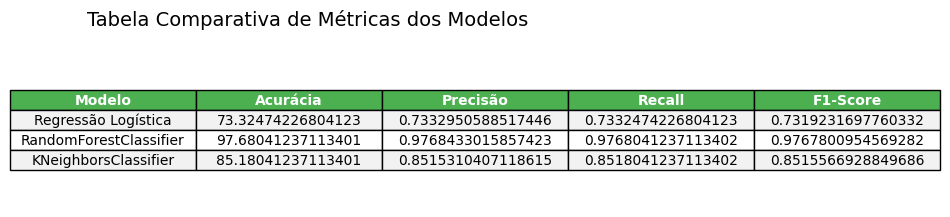

In [58]:
metricas = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'RandomForestClassifier', 'KNeighborsClassifier'],
    'Acurácia': [acuraciaLR, acuraciaRFC, acuraciaKNC],
    'Precisão': [precisaoLR, precisaoRFC, precisaoKNC],
    'Recall': [recallLR, recallRFC, recallKNC],
    'F1-Score': [f1LR, f1RFC, f1KNC]
})

fig, ax = plt.subplots(figsize=(10, 2)) # Adjust figure size as needed
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=metricas.values, colLabels=metricas.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2) # Adjust scale for better readability

# Style the header
for (i, j), cell in table.get_celld().items():
    if i == 0: # Header row
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4CAF50') # Green header background
    elif i > 0: # Body rows
        cell.set_facecolor('#f2f2f2' if (i-1) % 2 == 0 else 'white') # Alternate row colors

plt.title('Tabela Comparativa de Métricas dos Modelos', loc='left', fontsize=14, pad=20)
plt.show()

### Matrizes de Confusão

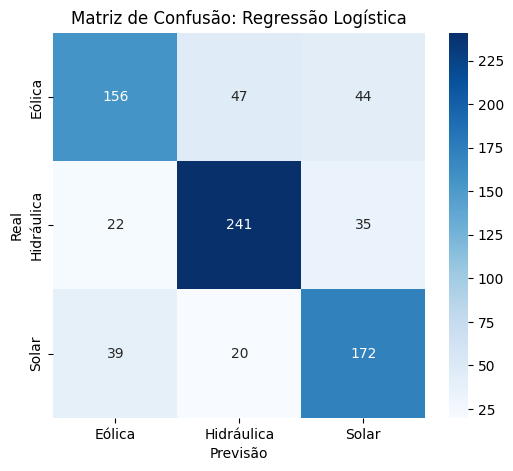

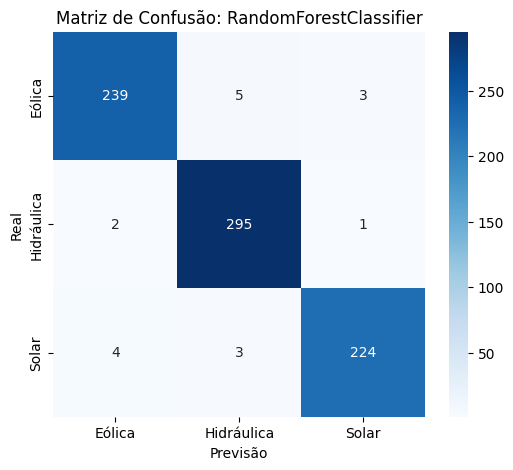

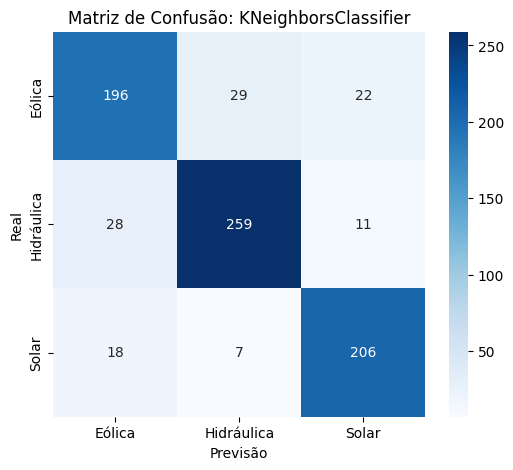

In [55]:
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Previsão')
    plt.ylabel('Real')
    plt.show()

labels = sorted(y.unique())

plot_confusion_matrix(y_test, y_predictLR, labels, 'Matriz de Confusão: Regressão Logística')
plot_confusion_matrix(y_test, y_predictRFC, labels, 'Matriz de Confusão: RandomForestClassifier')
plot_confusion_matrix(y_test, y_predictKNC, labels, 'Matriz de Confusão: KNeighborsClassifier')

### Interpretação dos Resultados

Com base na tabela comparativa de métricas e nas matrizes de confusão, podemos fazer as seguintes observações:

*   **Modelo Escolhido:** O **RandomForestClassifier** se destaca como o melhor modelo para este problema de classificação. Ele apresenta as maiores pontuações em todas as métricas (acurácia, precisão, recall e F1-Score), indicando que é o mais preciso e robusto na identificação das fontes de energia.

*   **Classes mais Confundidas (RandomForestClassifier):**
    Observando a matriz de confusão do RandomForestClassifier, o modelo apresenta uma performance excepcional com pouquíssimos erros. A maioria das previsões está na diagonal principal, indicando classificações corretas. As confusões são mínimas, mas podem ser notadas por pequenos números fora da diagonal.

    *   **Eólica:** Houve 3 casos onde o modelo previu 'Hidráulica' quando na verdade era 'Eólica'.
    *   **Hidráulica:** Houve 3 casos onde o modelo previu 'Eólica' quando na verdade era 'Hidráulica', e 1 caso onde previu 'Solar' quando era 'Hidráulica'.
    *   **Solar:** Houve 5 casos onde o modelo previu 'Hidráulica' quando era 'Solar'.

    Esses pequenos erros sugerem que pode haver alguma sobreposição nos padrões de dados entre essas classes, embora o modelo tenha conseguido distinguir a grande maioria corretamente.

*   **Por que potência/localização podem não bastar para uma aplicação real:**
    Embora o RandomForestClassifier tenha atingido uma alta acurácia (98%) usando apenas 'potencia_kw', 'latitude' e 'longitude', em uma aplicação real, esses atributos podem não ser suficientes por algumas razões:

    1.  **Variações Temporais e Climáticas:** A geração de energia (especialmente solar e eólica) é altamente dependente de fatores climáticos (insolação, velocidade do vento) e sazonais. A latitude e longitude fornecem a localização, mas não o contexto temporal ou as condições ambientais específicas em um determinado momento.
    2.  **Tecnologia e Eficiência:** Diferentes usinas podem ter tecnologias distintas e níveis de eficiência variados, mesmo com potência e localização semelhantes. Essas características não são capturadas pelos atributos atuais.
    3.  **Fatores Regulatórios e Operacionais:** Políticas energéticas, regulamentações, horários de operação, manutenção e disponibilidade de combustível (para hidrelétricas, por exemplo) podem influenciar a classificação e não são refletidos nos dados.
    4.  **Erro de Medição/Registro:** Os dados de potência e localização podem conter ruídos ou imprecisões, e contar apenas com eles pode propagar esses erros.
    5.  **Classes Adicionais:** Em um cenário real, podem existir outras fontes de energia (biomassa, geotérmica, termelétrica, etc.) que não estão representadas neste conjunto de dados, tornando o modelo incompleto para um problema mais abrangente.

    Para uma aplicação robusta, seria ideal incluir atributos adicionais como dados históricos de produção, informações climáticas, tipo de tecnologia da usina, data de instalação, e outros fatores operacionais e ambientais.